In [2]:
import numpy as np
import matplotlib.pyplot as plt

## FUNCTION DEFINITIONS

In [3]:
#Generates spins from spins.txt
def loadData():
    data = np.genfromtxt("spins.txt", dtype=int, delimiter=1)
    spins = 1-2*data 
    L = spins.shape[0]
    return spins, L

In [4]:
#the avg direction of spin is the magnetization of the lattice from -1 to 1
def magnetization(spins):
    return np.mean(spins)

In [5]:
#the delta Energy of changing one of the node in the lattice
def delE(i,j,J,H):
    
    #Applying Periodic Boundary Conditions
    if i==0:
        up=L-1
    else:
        up=i-1
    if i==L-1:
        down = 0
    else:
        down = i+1
    if j==0:
        left=L-1
    else:
        left=j-1
    if j==L-1:
        right = 0
    else:
        right = j+1

        
    sumsNeighbor = spins[up,j]+spins[down,j]+spins[i,left]+spins[i,right]

    E = -J*spins[i,j]*sumsNeighbor - H*spins[i,j]
    delE = 2*J*spins[i,j]*sumsNeighbor + 2*H*spins[i,j]
    return delE

In [6]:
#Does L*L random checks and determines whether the Spin can change using 
rng = np.random.default_rng()
def sweep(J,H,T):
    
    for x in range(L * L):
        i = rng.integers(0, L)
        j = rng.integers(0, L)
        dE = delE(i,j,J,H)
        
        if dE<= 0:
            spins[i, j] *= -1
        elif T>0:
            P = (np.e)**(-dE/T)
            if rng.random() <= P:
                spins[i, j] *= -1            

## Color Gradient of spins in Lattice

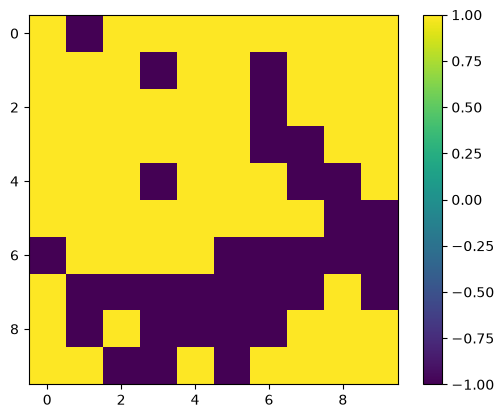

In [7]:
spins,L = loadData()
J = 1.0 #Coupling Strength J in our equation
T = 3 #Temperature
H = 0 #Magnetic Field Strength H in our equation

#Monte Carlo of 10 sweeps
for x in range(0,10):
    sweep(J,H,T)

plt.imshow(spins, vmin=-1, vmax=1)
plt.colorbar()
plt.show()

## Hysteresis Simulation

In [8]:
def findCoerciveField(HValues, MValues):
    for i in range(len(MValues) - 1):
        if MValues[i] == 0:
            return HValues[i]
        if MValues[i]*MValues[i + 1] < 0:
            H1 = HValues[i]
            H2 = HValues[i + 1]
            M1 = MValues[i]
            M2 = MValues[i + 1]
            Hc = H1+(-M1)*(H2-H1)/(M2-M1)
            return Hc
    return None

In [9]:
#Monte Carlo Sweep for each H, changing by dH each run
def Hysteresis(J,T,Hmax,dH,spins,L,amt):
    MDownValues = []
    HDownValues = []
    MUPValues = []
    HUPValues = []
    H = Hmax
    while H>=-Hmax:
        for x in range(0,amt):
            sweep(J,H,T)
        MDownValues.append(magnetization(spins))
        HDownValues.append(H)
        H -= dH

    H = -Hmax   
    while H<=Hmax:
        for x in range(0,amt):
            sweep(J,H,T)
        MUPValues.append(magnetization(spins))
        HUPValues.append(H)
        H += dH

    HcDown = findCoerciveField(HDownValues, MDownValues)
    HcUp = findCoerciveField(HUPValues, MUPValues)
    Hc = (abs(HcDown) + abs(HcUp)) / 2
    
    
    plt.plot(HDownValues, MDownValues, color="red")
    plt.plot(HUPValues, MUPValues, color="green")
    plt.xlabel("Magnetic Field H / J")
    plt.ylabel("Magnetization M")
    plt.title("Magnetization vs Magnetic Field")
    plt.grid()
    plt.show()
    return Hc

Temperature: 0


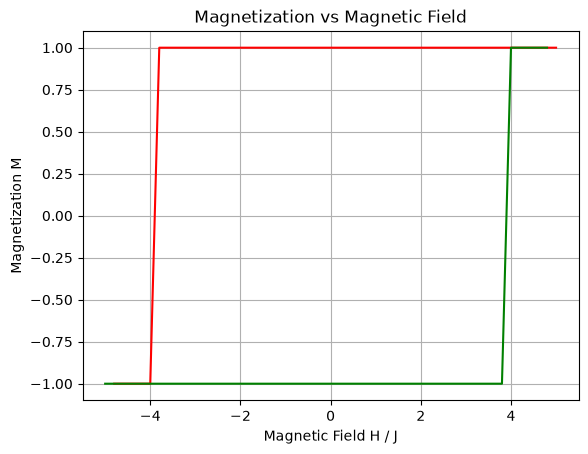

Temperature: 0.25


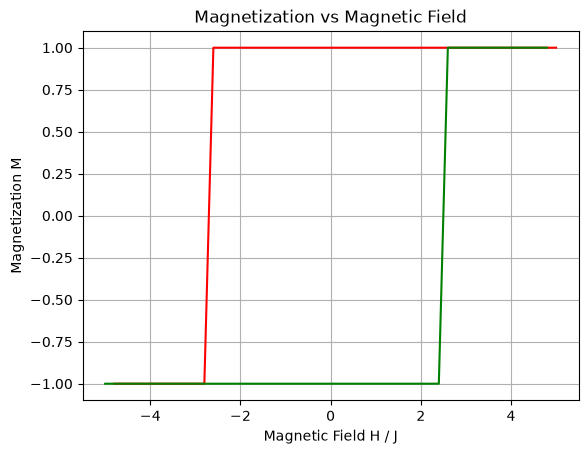

Temperature: 0.5


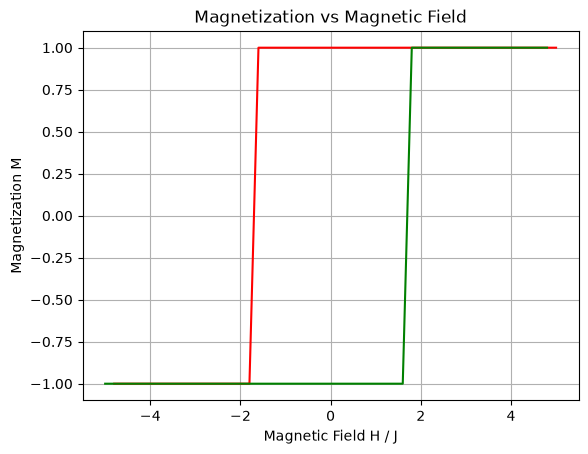

Temperature: 0.75


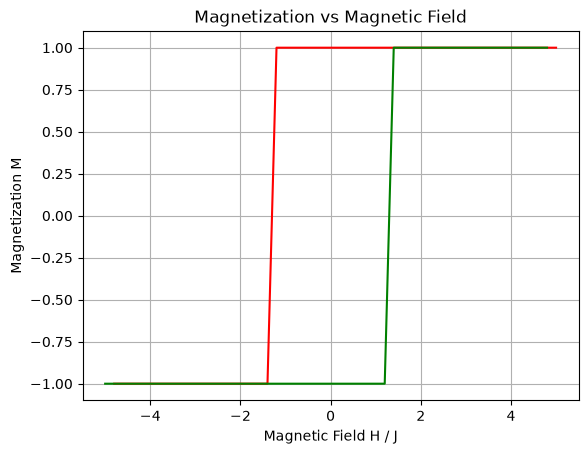

Temperature: 1.0


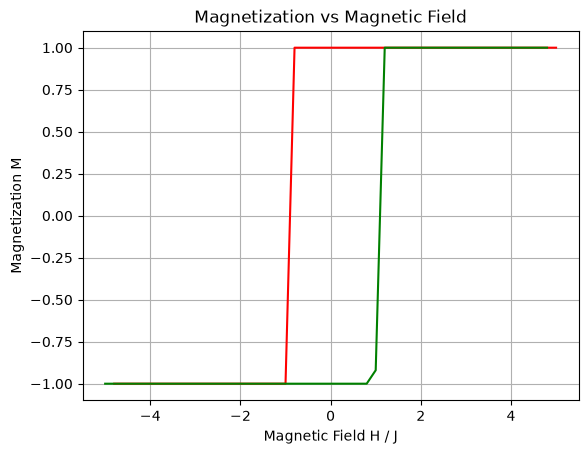

Temperature: 1.25


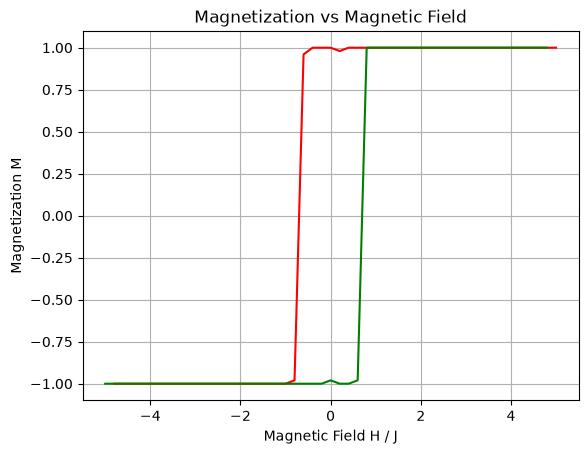

Temperature: 1.5


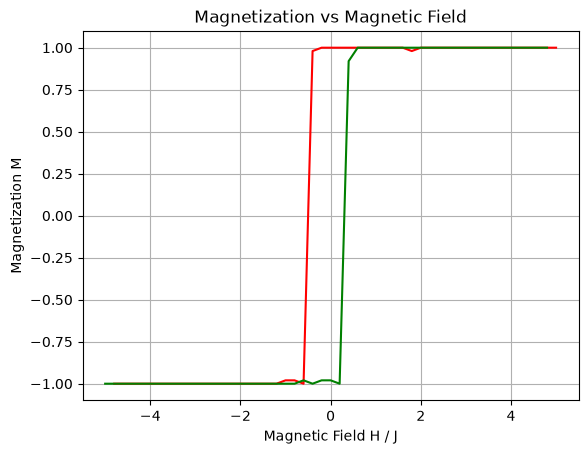

Temperature: 1.75


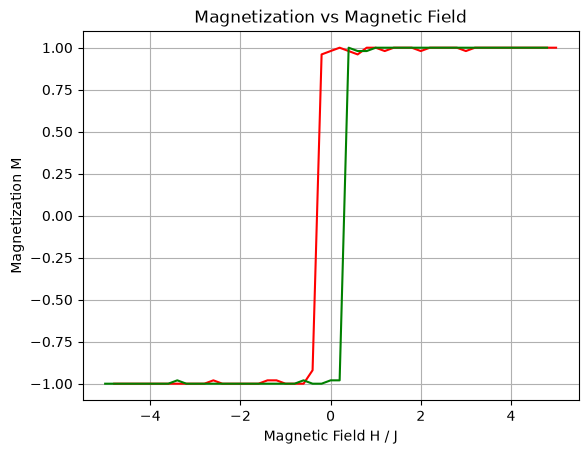

Temperature: 2.0


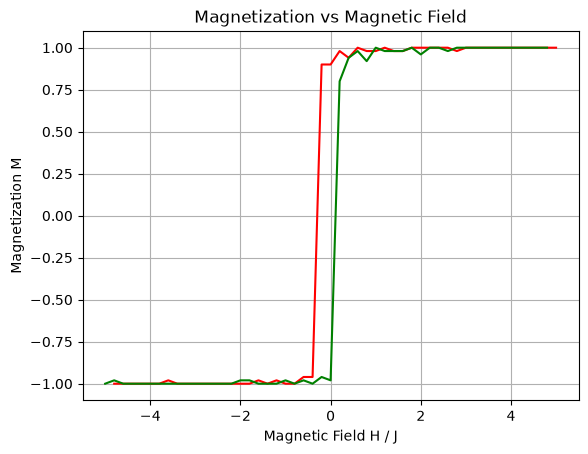

Temperature: 2.25


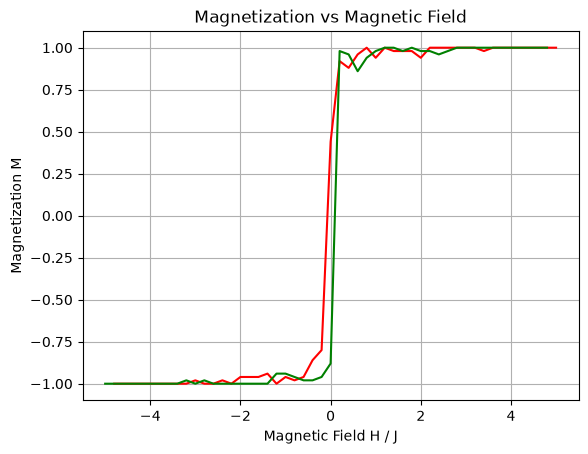

Temperature: 2.5


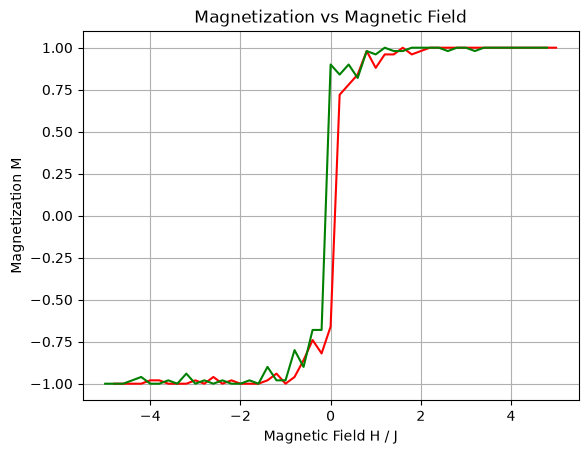

Temperature: 2.75


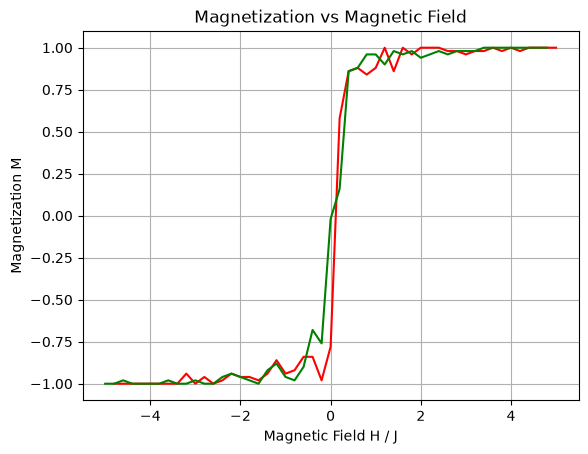

Temperature: 3.0


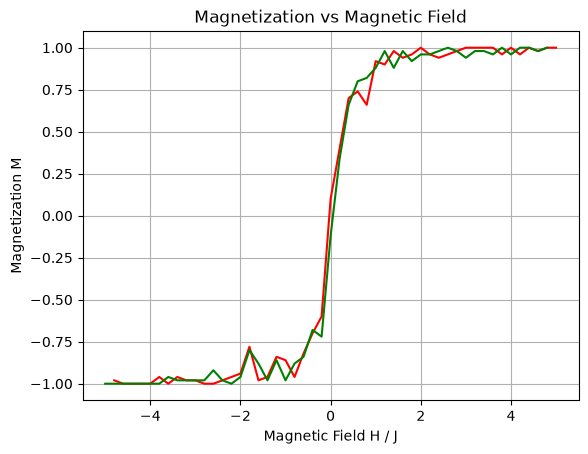

Temperature: 3.25


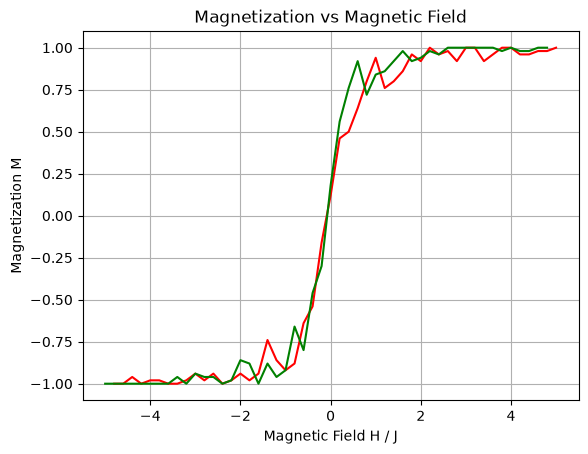

Temperature: 3.5


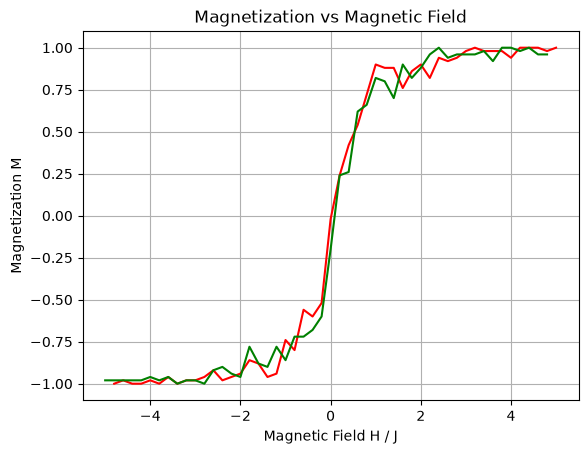

Temperature: 3.75


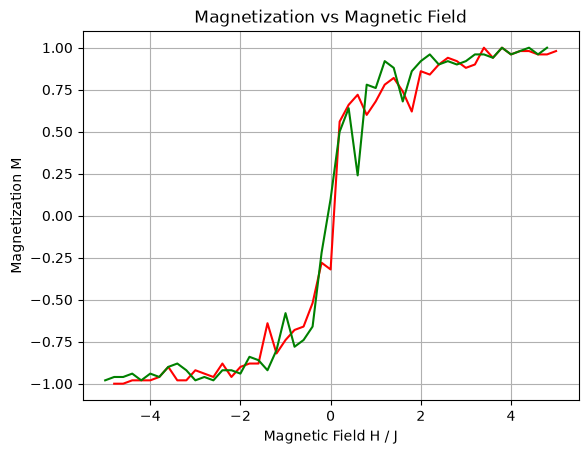

Temperature: 4.0


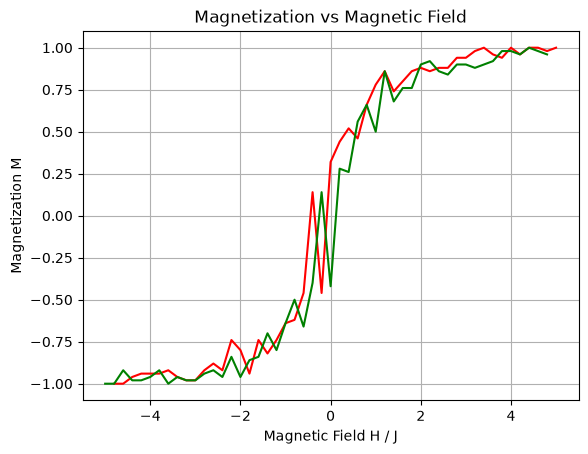

In [12]:
spins,L = loadData()
J = 1.0
T = 0
H = 5
dH = 0.2


#Syntax: Hysteresis(J,T,H,dH,spins,L,Sweeps)
dT=0.25
TValues=[]
HcValues=[]
while T<=4:
    print("Temperature:",T)
    TValues.append(T)
    HcValues.append(Hysteresis(J,T,H,dH,spins,L,100))
    spins,L = loadData()
    T+=dT

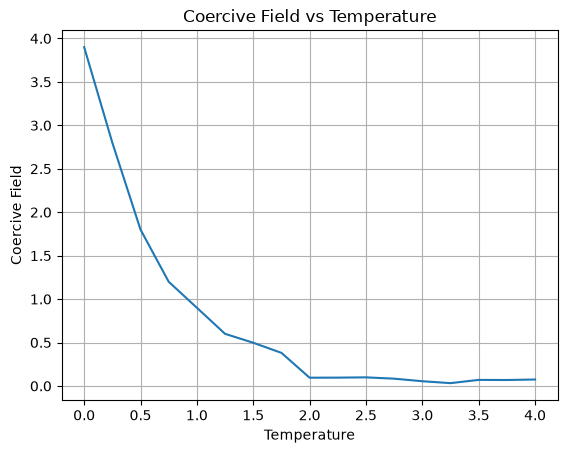

In [11]:
plt.plot(TValues, HcValues)
plt.xlabel("Temperature")
plt.ylabel("Coercive Field")
plt.title("Coercive Field vs Temperature")
plt.grid()
plt.show()

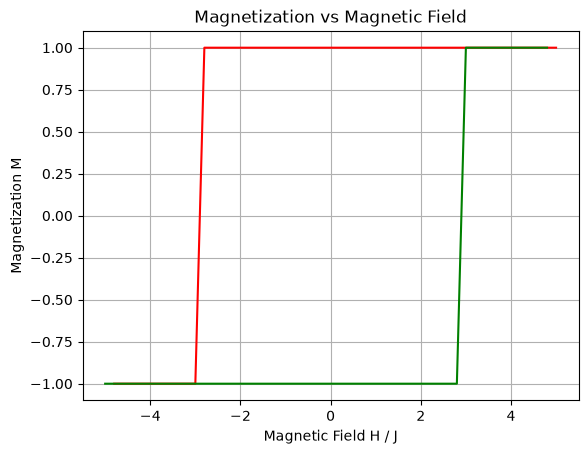

HC Value:  2.900000000000003


In [10]:
spins,L = loadData()
J = 1.0
T = 0.25
H = 5
dH = 0.2

#Syntax: Hysteresis(J,T,H,dH,spins,L,Sweeps)
print("HC Value: ",Hysteresis(J,T,H,dH,spins,L,100))
